### Part 2 of the Thesis

New filter approach.
A (undocumented) detection event of WT 2
Suspicious Signal Generator bearing front temperature

In [ ]:
from helperfunctions import helper as hfn
from helperfunctions import intern_constants as ic
from helperfunctions.pretty_print import PrettyPrint as pp
from helperfunctions.preprocessing import PreprocessingStep5
from helperfunctions.detection import Part2 as p2
import pandas as pd
from pathlib import Path
import numpy as np
import os
from glob import glob
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
#%matplotlib widget
%matplotlib inline
pd.set_option("display.max_columns", None)
#pd.set_option("display.max_rows", None)

ImportError: cannot import name 'ks_test' from 'helperfunctions.detection' (c:\Users\admin\Uni\bsc-arbeit\git\Explorative-AD-in-Wind-Turbine-SCADA-Data-Using-an-AE\src\helperfunctions\detection.py)

In [ ]:
cfg_part2 = hfn.TrainConfig(config_name="part2", choose_val_set=2)


{
  "config_name": "part2",
  "batch_size": 252,
  "epochs": 30,
  "lr": 0.001,
  "weight_decay": 0.0,
  "grad_clip_norm": 1.0,
  "patience": 5,
  "min_delta": 1e-06,
  "depth": null,
  "input_dim": 38,
  "base_width": 38,
  "width_decay": 0.5,
  "bottleneck_min": 2,
  "activation": "relu",
  "dropout": 0.0,
  "leaky_relu_slope": null,
  "seed": 32,
  "base_seed": 32,
  "T0": 10,
  "Tmult": 2,
  "eta_min_lower_bound": 1e-06,
  "val_split": 0.4,
  "layer_depths": [
    2,
    3,
    4,
    5
  ],
  "available_start": "2019-04-05 14:00:00",
  "available_end": "2022-12-31 23:50:00",
  "min_gap": 4320,
  "val_start_time": "2019-11-06 18:40:00",
  "val_end_time": "2020-04-01 04:00:00",
  "test_start_time": "2020-05-01 04:10:00",
  "test_end_time": "2022-12-31 23:50:00",
  "signal_cols": [
    "Ambient temperature (converter) (°C)",
    "Drive train acceleration (mm/ss)",
    "Gear oil inlet pressure (bar)",
    "Gear oil pump pressure (bar)",
    "Gearbox speed (RPM)",
    "Generator bearin

In [ ]:
test_eval_file = glob(os.path.join(ic.PATH_PART2_EVAL_TEST, "*.csv")) [0]
test_eval_df = pd.read_csv(test_eval_file, parse_dates=[ic.TS_COL])

display(test_eval_df.head())

,uid,Date and time,WT_ID,Mean Loss per Sample,RE_Ambient temperature (converter) (°C),RE_Drive train acceleration (mm/ss),RE_Gear oil inlet pressure (bar),RE_Gear oil pump pressure (bar),RE_Gearbox speed (RPM),RE_Generator bearing front temperature (°C),RE_Generator bearing rear temperature (°C),RE_Generator RPM (RPM),RE_Hub temperature (°C),RE_Motor current axis 1 (A),RE_Motor current axis 2 (A),RE_Motor current axis 3 (A),RE_Nacelle ambient temperature (°C),RE_Nacelle position (°),RE_Nacelle temperature (°C),RE_Power (kW),RE_Rotor bearing temp (°C),RE_Rotor speed (RPM),RE_Stator temperature 1 (°C),RE_Temp. top box (°C),RE_Temperature motor axis 1 (°C),RE_Temperature motor axis 2 (°C),RE_Temperature motor axis 3 (°C),RE_Vane position 1+2 (°),RE_Wind direction (°),RE_Wind speed (m/s),RE_Blade angle (pitch position) A (°),RE_Blade angle (pitch position) B (°),RE_Blade angle (pitch position) C (°),RE_Front bearing temperature (°C),RE_Gear oil inlet temperature (°C),RE_Gear oil temperature (°C),RE_Rear bearing temperature (°C),RE_Tower Acceleration X (mm/ss),RE_Tower Acceleration Y (mm/ss),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C),RE_Yaw bearing angle (°)
0,1588306200000000001,2020-05-01 04:10:00,1,0.021798,0.008148,0.094487,0.020666,0.021166,0.002876,0.011175,0.003134,0.002139,0.083261,0.000055,0.000006,0.006936,0.027010,2.388245e-01,0.002420,0.000163,0.001425,0.001798,1.648817e-06,1.111275e-02,0.002902,0.002989,0.003100,0.018406,0.000058,0.000525,0.002179,0.002669,0.002781,0.001968,0.000169,0.004524,0.000044,0.000239,0.012340,0.000073,0.000367,0.236192
1,1588306200000000002,2020-05-01 04:10:00,2,0.026611,0.005555,0.147881,0.003152,0.005707,0.000037,0.000812,0.001665,0.000005,0.008374,0.000661,0.001424,0.000864,0.001743,2.390153e-01,0.006600,0.005054,0.180388,0.000170,2.252205e-03,1.640601e-02,0.002016,0.003590,0.003878,0.027006,0.000309,0.002825,0.000692,0.000909,0.000992,0.014479,0.004077,0.037727,0.014320,0.001727,0.014470,0.003942,0.013449,0.237053
2,1588306200000000004,2020-05-01 04:10:00,4,0.002452,0.000042,0.000007,0.002139,0.001538,0.000092,0.000897,0.000340,0.000293,0.026001,0.000186,0.000001,0.001525,0.000315,9.567735e-05,0.038999,0.002810,0.001857,0.000648,1.571099e-09,1.076651e-07,0.000094,0.000615,0.000009,0.000876,0.000004,0.001630,0.000468,0.000294,0.000284,0.000529,0.000318,0.003309,0.000072,0.000651,0.005969,0.000130,0.000011,0.000130
3,1588306200000000005,2020-05-01 04:10:00,5,0.013120,0.005832,0.035099,0.013446,0.022986,0.000044,0.008692,0.004631,0.000002,0.000229,0.014190,0.004403,0.012072,0.003371,4.101939e-05,0.005850,0.001402,0.003673,0.000112,9.969746e-04,5.928122e-05,0.000172,0.000108,0.000001,0.000500,0.249002,0.008641,0.000214,0.000377,0.000418,0.002332,0.004244,0.015442,0.001185,0.018634,0.051762,0.007190,0.001146,0.000083
4,1588306200000000006,2020-05-01 04:10:00,6,0.013144,0.000221,0.043485,0.000567,0.001858,0.005117,0.000530,0.010470,0.001455,0.000081,0.000861,0.000829,0.000894,0.003858,2.060028e-08,0.005266,0.004495,0.000031,0.000075,1.441789e-03,1.015547e-02,0.047146,0.044287,0.046548,0.017712,0.236755,0.001082,0.001290,0.001459,0.000232,0.000188,0.000374,0.001174,0.001621,0.000152,0.001344,0.002955,0.003236,0.000237


In [ ]:
test_eval_clean = p2.drop_imputations(test_eval_df)

In [ ]:
theta = p2.load_threshold_table()

   WT_ID    k        mu     sigma  threshold   tp   fn     fp  precision  \
0      1  1.0  0.013096  0.029094    0.04219  7.0  1.0  236.0   0.028807   

   recall        f1  FAR_per_day  latency_mean  
0   0.875  0.055777     1.594595    111.714286  


In [ ]:
dets = test_eval_clean[test_eval_clean[ic.MEAN_LOSS_PER_SAMPLE] >= theta]
print(f"Total number of unfiltered Detections: {len(dets)}")

Total number of unfiltered Detections: 68809


### Power Curve 

In [ ]:
pre_step5 = PreprocessingStep5()
df_pc = pre_step5._prepare_power_curve()
df_pc.head()

,power_norm
0.00,0.0
0.01,0.0
0.02,0.0
0.03,0.0
0.04,0.0


In [ ]:
test_start = cfg_part2.test_start_time
test_end = cfg_part2.test_end_time

wt_farm_df = pd.read_csv(ic.PATH_PART2_WT_FARM /  "wt_farm_pc_df.csv")
wt_farm_df[ic.TS_COL] = pd.to_datetime(wt_farm_df[ic.TS_COL])
wt_farm_df.head()

,WT_ID,Date and time,Wind speed (m/s),Power (kW)
0,1,2020-05-01 04:10:00,5.180120,154.845861
1,1,2020-05-01 04:20:00,4.917112,125.039087
2,1,2020-05-01 04:30:00,5.379890,151.489965
3,1,2020-05-01 04:40:00,4.659290,100.066924
4,1,2020-05-01 04:50:00,5.240885,117.778430


### new


In [ ]:
catalog_df = pd.read_csv(ic.PATH_PART2_DETECTIONS / "catalog.csv")

In [ ]:
#filtered_cat = catalog_df[catalog_df["flag_sig_shift_event_mean"] == True]

filtered_cat = catalog_df[catalog_df["z_shift"] > 0]
filtered_cat = filtered_cat.sort_values(by=["z_shift"], ascending=False)

In [ ]:
display(filtered_cat.head())
display("filtered = ", len(filtered_cat))
display("total detections in catalog", len(catalog_df))

,WT_ID,re_at_ts,Date and time,signal_name,window_start,window_end,wind_center,n_baseline,mean_baseline,std_baseline,mean_event,std_event,value_at_ts,delta_at_ts,z_at_ts,delta_mean,z_shift
69,2,0.684403,2021-01-21 12:30:00,Generator bearing front temperature (°C),2021-01-11 02:10:00,2021-01-26 15:10:00,19.5,231,40.436923,4.409229,60.145190,10.842733,66.108621,25.671698,5.822265,19.708268,4.469777
738,15,1.219538,2022-09-04 04:10:00,Rotor bearing temp (°C),2022-08-30 04:30:00,2022-09-09 04:30:00,10.5,1531,28.206051,2.335001,36.070456,0.419233,35.471666,7.265615,3.111611,7.864405,3.368052
690,14,1.151810,2021-06-25 09:00:00,Generator bearing front temperature (°C),2021-06-20 06:30:00,2021-06-30 09:50:00,15.5,657,37.357630,3.338454,44.639760,2.647685,43.001666,5.644036,1.690613,7.282130,2.181288
688,14,1.195350,2021-06-25 09:00:00,Rotor bearing temp (°C),2021-06-20 06:30:00,2021-06-30 09:50:00,15.5,657,26.837207,2.484278,32.101889,0.462255,31.605000,4.767793,1.919187,5.264682,2.119200
550,12,0.907640,2020-10-10 19:00:00,Generator bearing front temperature (°C),2020-10-05 15:50:00,2020-10-15 21:10:00,11.5,1155,37.900581,4.653485,47.562265,11.513257,68.943334,31.042753,6.670862,9.661683,2.076225


'filtered = '

139

'total detections in catalog'

790

### column name adjustements and top event selection

In [ ]:
f_c_drop = filtered_cat.drop(columns=["window_start", "window_end"])
f_c_drop = f_c_drop[:1]

cols = ["re_at_ts","mean_baseline","std_baseline","mean_event","std_event","value_at_ts","delta_at_ts","z_at_ts","delta_mean",	"z_shift"]
f_c_drop[cols] = np.floor(f_c_drop[cols]*1000)/1000
f_c_drop = f_c_drop.rename(columns={"re_at_ts": "Squared Err. per Feat."})
f_c_drop_cp = f_c_drop.copy()

f_c_drop = f_c_drop.rename(columns={"signal_name": "Signal", 
                                    "wind_center": "Wind Center", 
                                    "n_baseline": "Samples in NBM", 
                                    "mean_baseline":"μ NBM",
                                    "std_baseline": "σ NBM",
                                    "mean_event": "μ Event",
                                    "std_event": "σ Event",
                                    "value_at_ts": "Value at ts",
                                    "delta_at_ts": "Δ at ts",
                                    "z_at_ts": "z at ts",
                                    "delta_mean": "Δ μ",
                                    "z_shift": "z event"
                                    })
display(f_c_drop)

ltx = f_c_drop.to_latex(index=False, escape=True, float_format="%.3f")
with open(ic.PATH_PRINTS/"p2_3_nbm.tex", "w", encoding="utf-8") as f:
    f.write(ltx)


,WT_ID,Squared Err. per Feat.,Date and time,Signal,Wind Center,Samples in NBM,μ NBM,σ NBM,μ Event,σ Event,Value at ts,Δ at ts,z at ts,Δ μ,z event
69,2,0.684,2021-01-21 12:30:00,Generator bearing front temperature (°C),19.5,231,40.436,4.409,60.145,10.842,66.108,25.671,5.822,19.708,4.469


In [ ]:
row = 0

In [ ]:
detection_ts = filtered_cat[ic.TS_COL].iloc[row]
detection_ts = pd.to_datetime(detection_ts)
anom_span = [(pd.to_datetime(filtered_cat["window_start"].iloc[row]), pd.to_datetime(filtered_cat["window_end"].iloc[row]))]
wt = filtered_cat[ic.WT_ID].iloc[row]


In [ ]:
print(detection_ts)
print(wt)

2021-01-21 12:30:00
2


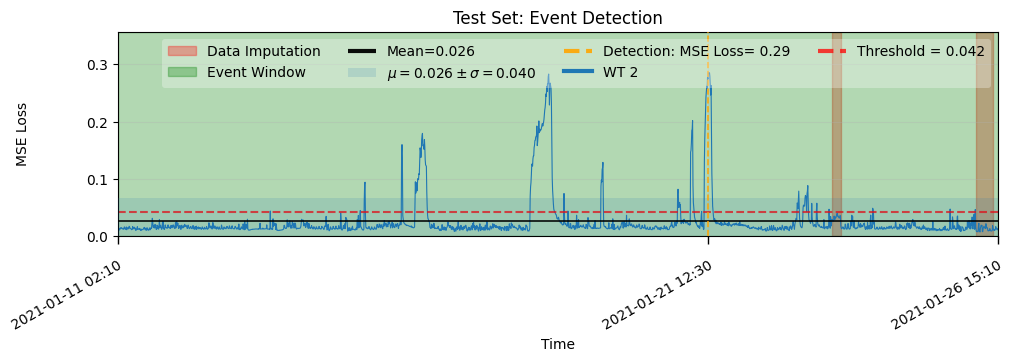

In [ ]:
loss = test_eval_df[(test_eval_df[ic.WT_ID] == wt) & (test_eval_df[ic.TS_COL] == detection_ts)][ic.MEAN_LOSS_PER_SAMPLE]
loss = f"{loss.iloc[0]: .2f}"

pp.print_loss(test_eval_df,
              dpi=300,
              #y_limits=((0,0.4),(0.4,100)),
              title=f"Test Set: Event Detection",
              wt_id= [wt],
              ts_range=anom_span[0],
              anomaly_spans=anom_span,
              mark_threshold=theta,
              anom_span_label="Event Window",
              detection_ts=[detection_ts],
              impute_label="Data Imputation",
              figsize=(11,3),
              save_filename="p2_3_mean_loss.png",
              detection_label=f"Detection: MSE Loss={loss}",
              y_label = "MSE Loss"
              )

In [ ]:
top_signals_wt = p2.get_top_sigs_for_detections(
    eval_df=p2.drop_imputations(test_eval_df),
    selected_detections=filtered_cat,
    wt_id=wt,
    top_n_signals=3
)

print(top_signals_wt)

[(Timestamp('2021-01-21 12:30:00'), ['RE_Gear oil temperature (°C)', 'RE_Rear bearing temperature (°C)', 'RE_Front bearing temperature (°C)'])]


In [ ]:
filtered_cat[ic.TS_COL] = pd.to_datetime(filtered_cat[ic.TS_COL])

In [ ]:
wt_windows = filtered_cat[(filtered_cat[ic.WT_ID] == wt)  & (filtered_cat[ic.TS_COL] == detection_ts)].iloc[[0]]

anomaly_spans_wt = [(pd.to_datetime(row["window_start"]), pd.to_datetime(row["window_end"])) for _,row in wt_windows.iterrows()]
anomaly_spans_wt = sorted(anomaly_spans_wt, key=lambda span: span[0])
print(anomaly_spans_wt)
min_ts = anomaly_spans_wt[0][0]
max_ts = anomaly_spans_wt[-1][1]

[(Timestamp('2021-01-11 02:10:00'), Timestamp('2021-01-26 15:10:00'))]


[(Timestamp('2021-01-11 02:10:00'), Timestamp('2021-01-26 15:10:00'))]


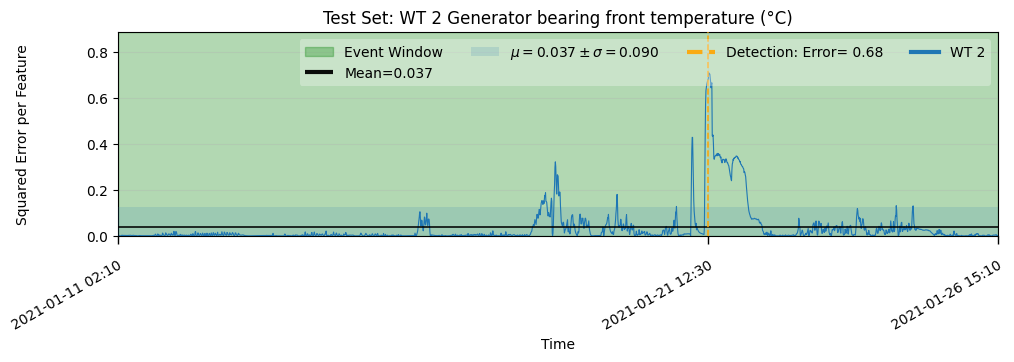

In [ ]:
sig = "Generator bearing front temperature (°C)"
loss = test_eval_df[(test_eval_df[ic.WT_ID] == wt) & (test_eval_df[ic.TS_COL] == detection_ts)][f"RE_{sig}"]
loss = f"{loss.iloc[0]: .2f}"
print(anom_span)
pp.print_loss(test_eval_df,
                    dpi=300,
                    title=f"Test Set: WT {wt} {sig}",
                    wt_id= [wt],
                    values=f"RE_{sig}",
                    ts_range=(min_ts, max_ts),
                    anomaly_spans=anom_span,
                    mark_threshold=None,
                    anom_span_label="Event Window",
                    detection_ts=[detection_ts],
                    detection_label=f"Detection: Error={loss}",
                    impute_label="Data Imputation",
                    figsize=(11,3),
                    save_filename=f"p2_3_signal_loss_{sig}",
                    y_label= "Squared Error per Feature",
                    )


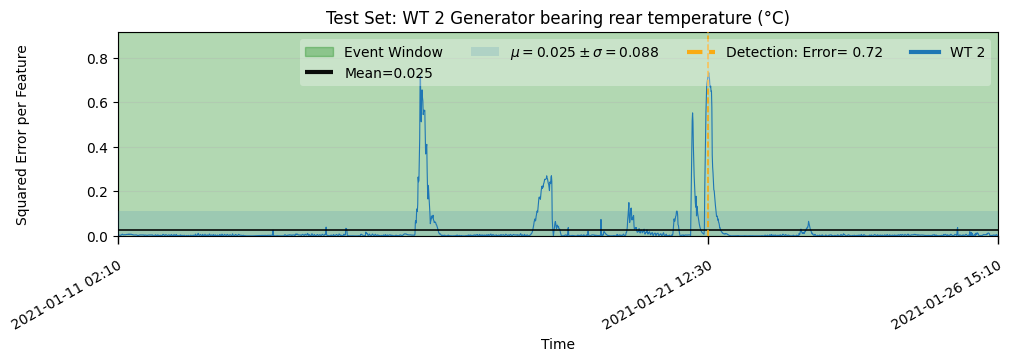

In [ ]:
sig = "Generator bearing rear temperature (°C)"
loss = test_eval_df[(test_eval_df[ic.WT_ID] == wt) & (test_eval_df[ic.TS_COL] == detection_ts)][f"RE_{sig}"]
loss = f"{loss.iloc[0]: .2f}"
pp.print_loss(test_eval_df,
                    dpi=300,
                    title=f"Test Set: WT {wt} {sig}",
                    wt_id= [wt],
                    values=f"RE_{sig}",
                    ts_range=(min_ts, max_ts),
                    anomaly_spans=anom_span,
                    mark_threshold=None,
                    anom_span_label="Event Window",
                    detection_ts=[detection_ts],
                    detection_label=f"Detection: Error={loss}",
                    impute_label="Data Imputation",
                    figsize=(11,3),
                    save_filename=f"p2_3_signal_loss_{sig}",
                    y_label= "Squared Error per Feature",
                    )

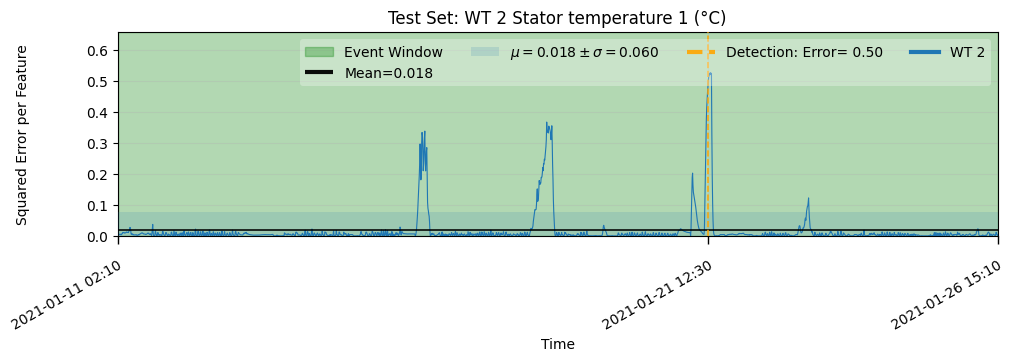

In [ ]:
sig = "Stator temperature 1 (°C)"
loss = test_eval_df[(test_eval_df[ic.WT_ID] == wt) & (test_eval_df[ic.TS_COL] == detection_ts)][f"RE_{sig}"]
loss = f"{loss.iloc[0]: .2f}"
pp.print_loss(test_eval_df,
                    dpi=300,
                    title=f"Test Set: WT {wt} {sig}",
                    wt_id= [wt],
                    values=f"RE_{sig}",
                    ts_range=(min_ts, max_ts),
                    anomaly_spans=anom_span,
                    mark_threshold=None,
                    anom_span_label="Event Window",
                    detection_ts=[detection_ts],
                    detection_label=f"Detection: Error={loss}",
                    impute_label="Data Imputation",
                    figsize=(11,3),
                    save_filename=f"p2_3_signal_loss_{sig}",
                    y_label= "Squared Error per Feature",
                    )

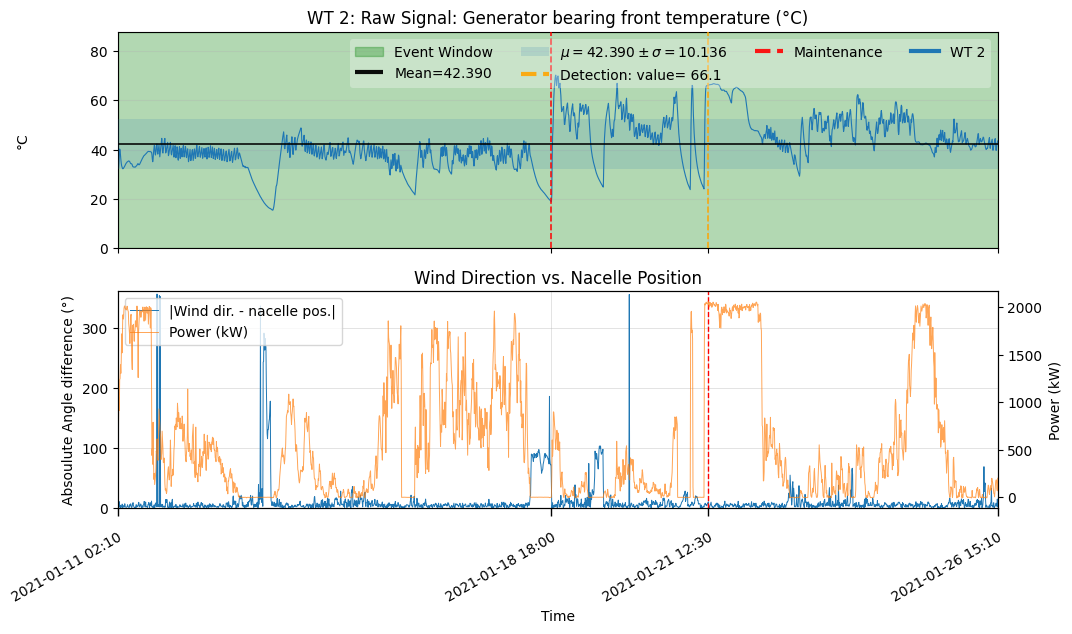

In [ ]:
sig = "Generator bearing front temperature (°C)"
#date before large shift occured in generator bearing front temp.
maintenance = pd.to_datetime("2021-01-18 18:00:00") # see logs

fp = Path(ic.PATH_IMPUTED).glob(f"WT_ID_{wt}*")
wt_df = pd.read_csv(next(iter(fp)), parse_dates=[ic.TS_COL])
wt_df = wt_df[(wt_df[ic.TS_COL] >= cfg_part2.test_start_time) & (wt_df[ic.TS_COL] <= cfg_part2.test_end_time)]
val = wt_df[(wt_df[ic.WT_ID] == wt) & (wt_df[ic.TS_COL] == detection_ts)][sig]

val = f"{val.iloc[0]: .1f}"

pp.print_loss(wt_df, 
                values=sig,
                title=f"WT {wt}: Raw Signal: {sig}",
                wt_id=[wt],
                ts_range= (min_ts, max_ts),
                anomaly_spans=anomaly_spans_wt,
                detection_label=f"Detection: value={val}",
                detection_ts= [detection_ts],
                marker=maintenance, 
                y_label = pp.unit(sig),
                anom_span_label="Event Window",
                impute_label="Data Imputation",
                figsize=(11,7),
                #save_filename=None,
                save_filename=f"p2_3_raw_signals_{sig}_plus_wind_nacelle",
                add_wind_vs_nacelle=True,
                )

In [ ]:
power = wt_df[wt_df[ic.TS_COL] == (maintenance + pd.Timedelta(hours=2))]
display(power)


,WT_ID,Ambient temperature (converter) (°C),Date and time,Drive train acceleration (mm/ss),Gear oil inlet pressure (bar),Gear oil pump pressure (bar),Gearbox speed (RPM),Generator bearing front temperature (°C),Generator bearing rear temperature (°C),Generator RPM (RPM),Hub temperature (°C),Motor current axis 1 (A),Motor current axis 2 (A),Motor current axis 3 (A),Nacelle ambient temperature (°C),Nacelle position (°),Nacelle temperature (°C),Power (kW),Rotor bearing temp (°C),Rotor speed (RPM),Stator temperature 1 (°C),Temp. top box (°C),Temperature motor axis 1 (°C),Temperature motor axis 2 (°C),Temperature motor axis 3 (°C),Vane position 1+2 (°),Wind direction (°),Wind speed (m/s),Blade angle (pitch position) A (°),Blade angle (pitch position) B (°),Blade angle (pitch position) C (°),Front bearing temperature (°C),Gear oil inlet temperature (°C),Gear oil temperature (°C),Rear bearing temperature (°C),Tower Acceleration X (mm/ss),Tower Acceleration Y (mm/ss),Transformer cell temperature (°C),Transformer temperature (°C),Yaw bearing angle (°)
243427,2,5.662069,2021-01-18 20:00:00,5.644661,195.190988,584.554395,1533.297374,68.47931,48.82931,1532.140148,13.0,-0.002198,-1.192093e-07,0.490196,5.603448,215.456528,19.886207,584.038444,20.906896,14.534346,63.398276,11.582759,19.0,18.97069,18.0,-8.069361,209.438768,7.814756,0.0,0.0,0.0,71.060345,48.960345,52.974138,61.065517,47.078359,21.813783,7.686207,41.09138,215.456528


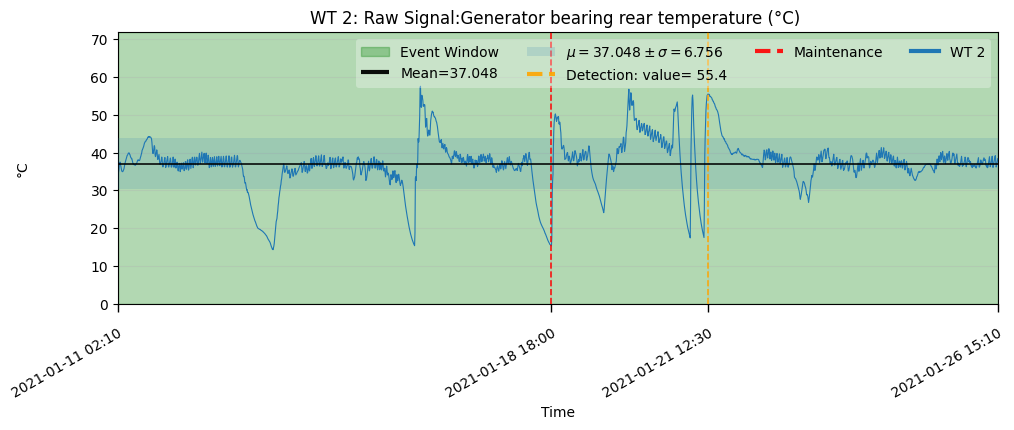

In [ ]:
sig = "Generator bearing rear temperature (°C)"
val = wt_df[(wt_df[ic.WT_ID] == wt) & (wt_df[ic.TS_COL] == detection_ts)][sig]
val = f"{val.iloc[0]: .1f}"
pp.print_loss(wt_df, 
                values=sig,
                title=f"WT {wt}: Raw Signal:{sig} ",
                wt_id=[wt],
                ts_range= (min_ts, max_ts),
                anomaly_spans=anomaly_spans_wt,
                detection_label=f"Detection: value={val}",
                detection_ts= [detection_ts],
                y_label = pp.unit(sig),
                anom_span_label="Event Window",
                impute_label="Data Imputation",
                figsize=(11,4),
                save_filename=f"p2_3_raw_signals_{sig}.png",
                marker=maintenance,
                )

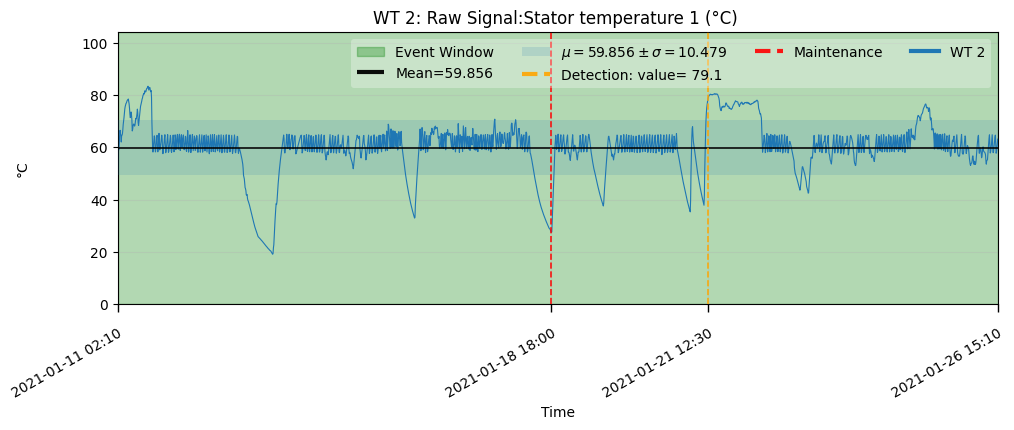

In [ ]:
sig = "Stator temperature 1 (°C)"
val = wt_df[(wt_df[ic.WT_ID] == wt) & (wt_df[ic.TS_COL] == detection_ts)][sig]
val = f"{val.iloc[0]: .1f}"
pp.print_loss(wt_df, 
                values=sig,
                title=f"WT {wt}: Raw Signal:{sig} ",
                wt_id=[wt],
                ts_range= (min_ts, max_ts),
                anomaly_spans=anomaly_spans_wt,
                detection_label=f"Detection: value={val}",
                detection_ts= [detection_ts],
                y_label = pp.unit(sig),
                anom_span_label="Event Window",
                impute_label="Data Imputation",
                figsize=(11,4),
                save_filename=f"p2_3_raw_signals_{sig}.png",
                marker=maintenance,
                add_wind_vs_nacelle=False
                )

# Descriptive Analysis

In [ ]:
thermal_signals = [sig for sig in hfn.load_feature_order() if "(°C)" in sig]
for sig in thermal_signals:
    print(sig)

Ambient temperature (converter) (°C)
Generator bearing front temperature (°C)
Generator bearing rear temperature (°C)
Hub temperature (°C)
Nacelle ambient temperature (°C)
Nacelle temperature (°C)
Rotor bearing temp (°C)
Stator temperature 1 (°C)
Temp. top box (°C)
Temperature motor axis 1 (°C)
Temperature motor axis 2 (°C)
Temperature motor axis 3 (°C)
Front bearing temperature (°C)
Gear oil inlet temperature (°C)
Gear oil temperature (°C)
Rear bearing temperature (°C)
Transformer cell temperature (°C)
Transformer temperature (°C)


In [ ]:
display(hfn.load_feature_order())

['Ambient temperature (converter) (°C)',
 'Drive train acceleration (mm/ss)',
 'Gear oil inlet pressure (bar)',
 'Gear oil pump pressure (bar)',
 'Gearbox speed (RPM)',
 'Generator bearing front temperature (°C)',
 'Generator bearing rear temperature (°C)',
 'Generator RPM (RPM)',
 'Hub temperature (°C)',
 'Motor current axis 1 (A)',
 'Motor current axis 2 (A)',
 'Motor current axis 3 (A)',
 'Nacelle ambient temperature (°C)',
 'Nacelle position (°)',
 'Nacelle temperature (°C)',
 'Power (kW)',
 'Rotor bearing temp (°C)',
 'Rotor speed (RPM)',
 'Stator temperature 1 (°C)',
 'Temp. top box (°C)',
 'Temperature motor axis 1 (°C)',
 'Temperature motor axis 2 (°C)',
 'Temperature motor axis 3 (°C)',
 'Vane position 1+2 (°)',
 'Wind direction (°)',
 'Wind speed (m/s)',
 'Blade angle (pitch position) A (°)',
 'Blade angle (pitch position) B (°)',
 'Blade angle (pitch position) C (°)',
 'Front bearing temperature (°C)',
 'Gear oil inlet temperature (°C)',
 'Gear oil temperature (°C)',
 'Rear 

In [ ]:
cpus = os.cpu_count() - 1
alpha = 0.05
def proc_col(col:str, wt_df, det_ts: pd.Timestamp, offset: pd.Timedelta, alpha:float):
    try:
        pr = ks.run_prewhitening_ks_pipeline(
        df=wt_df,
        col=col,
        ts_det=det_ts,
        offset=offset,
        )
        return {"ok": True, "col": col, "res": pr, "err": None}
    except Exception as e:
        return {"ok": False, "col": col, "res": None, "err": e}
    
jobs = Parallel(n_jobs=cpus, backend="loky")(delayed(proc_col)(col,wt_df,detection_ts, pd.Timedelta(days=7),alpha=alpha) for col in tqdm(thermal_signals))

for j in jobs:
    if j["ok"] == False:
        raise ValueError(f"Error occured")

pipeline_results = [j["res"] for j in jobs]
    

  0%|          | 0/18 [00:00<?, ?it/s]

In [ ]:
df_total = ks.report_total_many(pipeline_results, alpha)


In [ ]:
df_total = df_total[df_total["cliff's delta (raw)"] > 0]
df_total = df_total.sort_values(by=["cliff's delta (raw)"], ascending=[False])
display(df_total)
df_total = df_total.loc[[1,7,2]]
display(df_total)
relevant_sigs = df_total["signal"].tolist()
print(relevant_sigs)

,wt id,ts center,signal,∆ median (raw),∆ ln σ (raw),cliff's delta (raw)
1,2,2021-01-21 12:30:00,Generator bearing front temperature (°C),6.685,-0.321,0.481
10,2,2021-01-21 12:30:00,Temperature motor axis 2 (°C),8.210,0.157,0.287
11,2,2021-01-21 12:30:00,Temperature motor axis 3 (°C),8.457,0.164,0.278
9,2,2021-01-21 12:30:00,Temperature motor axis 1 (°C),8.505,0.123,0.272
6,2,2021-01-21 12:30:00,Rotor bearing temp (°C),1.060,-0.437,0.204
14,2,2021-01-21 12:30:00,Gear oil temperature (°C),2.029,-0.360,0.198
7,2,2021-01-21 12:30:00,Stator temperature 1 (°C),1.177,-0.160,0.195
13,2,2021-01-21 12:30:00,Gear oil inlet temperature (°C),0.948,-0.394,0.176
12,2,2021-01-21 12:30:00,Front bearing temperature (°C),2.457,-0.516,0.103
15,2,2021-01-21 12:30:00,Rear bearing temperature (°C),3.685,-0.343,0.100


,wt id,ts center,signal,∆ median (raw),∆ ln σ (raw),cliff's delta (raw)
1,2,2021-01-21 12:30:00,Generator bearing front temperature (°C),6.685,-0.321,0.481
7,2,2021-01-21 12:30:00,Stator temperature 1 (°C),1.177,-0.160,0.195
2,2,2021-01-21 12:30:00,Generator bearing rear temperature (°C),0.443,-0.751,0.069


['Generator bearing front temperature (°C)', 'Stator temperature 1 (°C)', 'Generator bearing rear temperature (°C)']


In [ ]:
os.makedirs(ic.PATH_PART2_KS_TEST, exist_ok=True)
df_total.to_csv(ic.PATH_PART2_KS_TEST / "wt2_ks_test.csv", index=False)

ltx6 = df_total.to_latex(index=False, escape=True, float_format="%.3f")

with open(ic.PATH_PRINTS/"p2_31_ks.tex", "w", encoding="utf-8") as f:
    f.write(ltx6)
    

In [ ]:
jobs = Parallel(n_jobs=cpus, backend="loky")(delayed(proc_col)(col,wt_df,detection_ts, pd.Timedelta(days=60),alpha=alpha) for col in tqdm(thermal_signals))

for j in jobs:
    if j["ok"] == False:
        raise ValueError(f"Error occured")

pipeline_results2 = [j["res"] for j in jobs]
df_total2 = ks.report_total_many(pipeline_results2, alpha)


  0%|          | 0/18 [00:00<?, ?it/s]

In [ ]:
df_total2 = df_total2[df_total2["cliff's delta (raw)"] > 0]
df_total2 = df_total2.sort_values(by=["cliff's delta (raw)"], ascending=[False])
display(df_total2)


,wt id,ts center,signal,∆ median (raw),∆ ln σ (raw),cliff's delta (raw)
6,2,2021-01-21 12:30:00,Rotor bearing temp (°C),2.834,0.102,0.409
1,2,2021-01-21 12:30:00,Generator bearing front temperature (°C),2.443,0.160,0.246
10,2,2021-01-21 12:30:00,Temperature motor axis 2 (°C),6.914,-0.072,0.150
9,2,2021-01-21 12:30:00,Temperature motor axis 1 (°C),7.208,-0.066,0.149
11,2,2021-01-21 12:30:00,Temperature motor axis 3 (°C),7.227,-0.066,0.148
17,2,2021-01-21 12:30:00,Transformer temperature (°C),4.168,0.053,0.108
7,2,2021-01-21 12:30:00,Stator temperature 1 (°C),0.907,-0.027,0.106
2,2,2021-01-21 12:30:00,Generator bearing rear temperature (°C),0.309,-0.095,0.078
15,2,2021-01-21 12:30:00,Rear bearing temperature (°C),0.710,-0.006,0.049
16,2,2021-01-21 12:30:00,Transformer cell temperature (°C),0.225,-0.727,0.046


In [ ]:
keep_idx = [1,7,2]
df_total2 = df_total2.loc[keep_idx]
display(df_total2)


,wt id,ts center,signal,∆ median (raw),∆ ln σ (raw),cliff's delta (raw)
1,2,2021-01-21 12:30:00,Generator bearing front temperature (°C),2.443,0.160,0.246
7,2,2021-01-21 12:30:00,Stator temperature 1 (°C),0.907,-0.027,0.106
2,2,2021-01-21 12:30:00,Generator bearing rear temperature (°C),0.309,-0.095,0.078


In [ ]:
df_total2.to_csv(ic.PATH_PART2_KS_TEST / "wt2_ks_test_wide_range.csv", index=False)
ltx7 = df_total2.to_latex(index=False, escape=True, float_format="%.3f")

with open(ic.PATH_PRINTS/"p2_31_ks_wide.tex", "w", encoding="utf-8") as f:
    f.write(ltx7)

In [ ]:
ltx6 = df_total.to_latex(index=False, escape=True, float_format="%.3f")

with open(ic.PATH_PRINTS/"p2_31_ks.tex", "w", encoding="utf-8") as f:
    f.write(ltx6)
    

In [ ]:
wind_col = "Wind speed (m/s)"
power_col = "Power (kW)"
df_det_keys = filtered_cat[[ic.WT_ID, ic.TS_COL]].copy()
df_det_keys2 = df_det_keys.drop_duplicates([ic.WT_ID, ic.TS_COL])
df_det_points = df_det_keys2.merge(
    wt_farm_df[[ic.WT_ID,ic.TS_COL, wind_col, power_col]],
    on=[ic.WT_ID, ic.TS_COL],
    how="left",
    validate="one_to_one"
)

df_det_points.head()

,WT_ID,Date and time,Wind speed (m/s),Power (kW)
0,2,2021-01-21 12:30:00,19.788621,2063.255827
1,15,2022-09-04 04:10:00,10.580885,1533.292464
2,14,2021-06-25 09:00:00,15.217580,2040.211458
3,12,2020-10-10 19:00:00,11.061830,1735.781124
4,13,2022-07-08 22:50:00,10.543835,1471.578526


c:\Users\admin\Uni\Abschlussarbeit\github\BSc-Thesis-Multi-Wind-Turbine-AD\src\helperfunctions\pretty_print.py:975: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  t_num = t.view("int64").to_numpy()


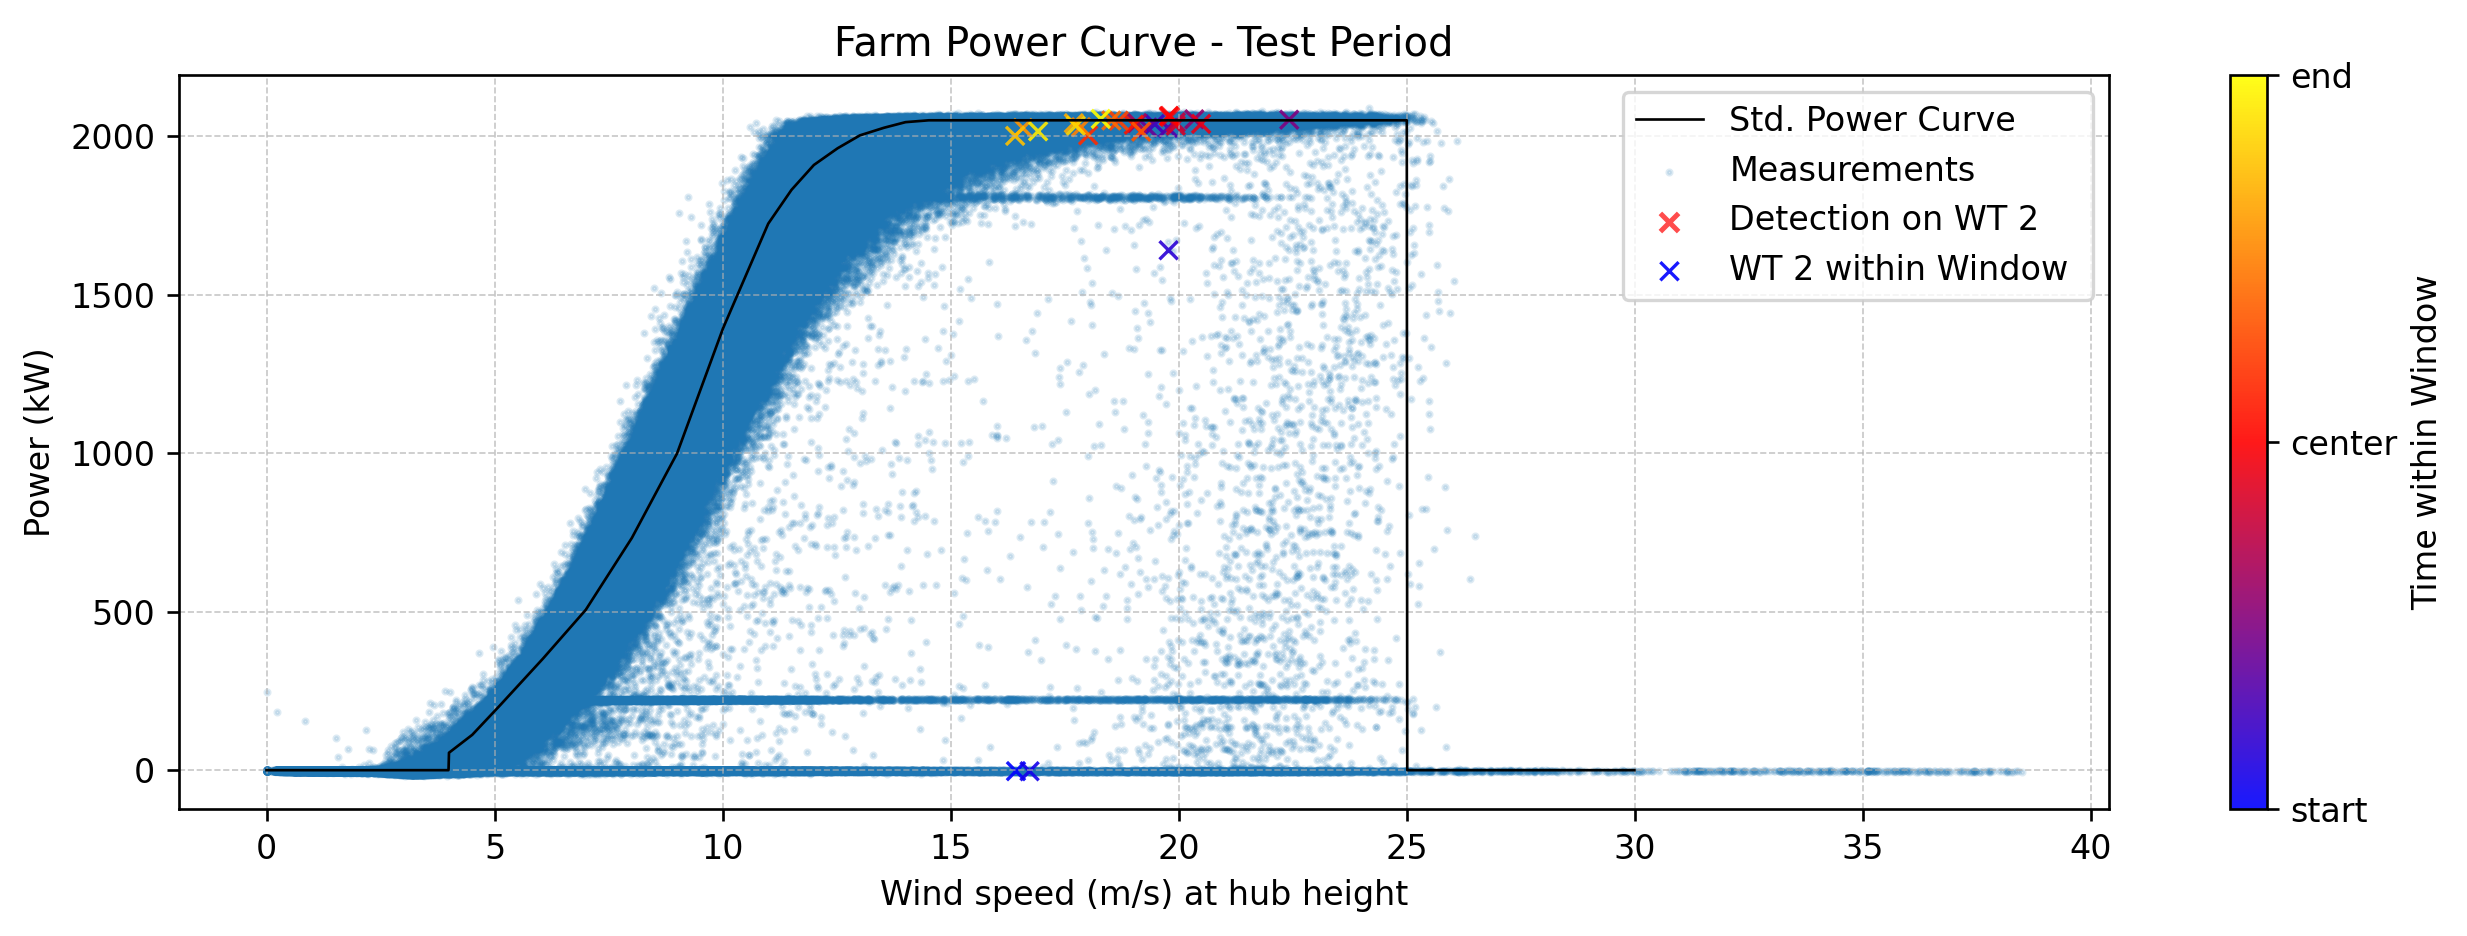

In [ ]:
pp.print_powercurve(df_pc=df_pc,
                    df_wts=p2.drop_imputations( wt_farm_df),
                    df_detections=df_det_points[(df_det_points[ic.WT_ID]== wt) & (df_det_points[ic.TS_COL]==detection_ts )],
                    detections_label=f"Detection on WT {wt}",
                    highlight_wt=wt,
                    highlight_ts_range=(pd.to_datetime(detection_ts )-pd.Timedelta(hours=2), pd.to_datetime(detection_ts )+pd.Timedelta(hours=2)),
                    alpha_det=0.7,
                    fig_size=(11,4),
                    save_dir=Path(ic.PATH_PRINTS),
                    file_name="p2_3_pc",
                    )

In [ ]:
# pp.plot_wind_vs_nacelle(df=wt_df, 
#                         ts_mark=detection_ts, 
#                         ts_range=(detection_ts - pd.Timedelta(days=5), 
#                                   detection_ts + pd.Timedelta(days=5)),
#                         save_filename="p2_3_wind_dir_nacelle_pos.png")

In [ ]:
# pp.print_loss(wt_df, 
#                   values=power_col,
#                   title=f"WT {wt}: Raw Signal:{power_col} ",
#                   ts_range= (min_ts, max_ts),
#                   anomaly_spans=anomaly_spans_wt,
#                   detection_label="Detected Anomaly",
#                   detection_ts= [ts],
#                   y_label = power_col[-3:-1],
#                   anom_span_label="Anomaly Window",
#                   save_filename="p2_3_raw_power.png",
#                   figsize=(10,6))

In [ ]:
print(wt)

2


In [ ]:
status_logs = pd.read_csv(ic.PATH_PENMANSHIEL / f"Status_Logs_Complete_ID_{wt}.csv")
status_logs["Timestamp start"] = pd.to_datetime(status_logs["Timestamp start"], errors="coerce")
status_logs["Timestamp end"] = pd.to_datetime(status_logs["Timestamp end"], errors="coerce")

In [ ]:
display(status_logs.head())

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category,WT_ID,Global contract category,Custom contract category
0,2016-06-03 08:54:48,2016-06-14 11:42:17,266:47:29,Stop,100,Safety chain open,NaN,Safety chain (13),Forced outage,2,NaN,NaN
1,2016-06-03 08:54:48,2016-06-03 08:59:00,00:04:12,Warning,5720,Brake accumulator defect,NaN,Warnings (27),NaN,2,NaN,NaN
2,2016-06-10 20:29:38,2016-06-14 11:46:13,87:16:35,Warning,3870,Overload transformer fan outlet air,NaN,Warnings (27),Full Performance,2,NaN,NaN
3,2016-06-10 20:34:56,2016-06-10 20:36:10,00:01:14,Warning,3860,Maintenance LV HRC fuse,NaN,Warnings (27),NaN,2,NaN,NaN
4,2016-06-11 01:34:01,2016-06-12 01:06:54,23:32:53,Warning,7324,Check time synchronization,NaN,Warnings (27),NaN,2,NaN,NaN


In [ ]:
print(detection_ts)

2021-01-21 12:30:00


In [ ]:
filter = status_logs[( detection_ts >= status_logs["Timestamp start"] ) & (detection_ts <= status_logs["Timestamp end"] )]

display(filter)

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category,WT_ID,Global contract category,Custom contract category


In [ ]:
delta = pd.Timedelta(days=3)
det_start = detection_ts - delta
det_end = detection_ts + delta

In [ ]:
filter = status_logs[(status_logs["Timestamp start"] <= det_end) & (status_logs["Timestamp end"] >= det_start)]
display(filter["Status"].unique())
print(detection_ts)
a = filter[filter["Status"] == "Stop"]
b =filter[filter["Status"] == "Warning"]
stopwarn = pd.concat([a,b], axis=0)
stopwarn = stopwarn.sort_values(by=["Timestamp start"], ascending=[True])
stopwarn = stopwarn.drop(["Comment", "Custom contract category","Global contract category"],axis=1)

display(stopwarn)
#display(filter[filter["Status"] == "Informational"])


array(['Stop', 'Informational', 'Warning', 'Communication'], dtype=object)

2021-01-21 12:30:00


,Timestamp start,Timestamp end,Duration,Status,Code,Message,Service contract category,IEC category,WT_ID
38807,2021-01-18 09:00:05,2021-01-18 18:03:01,09:02:56,Stop,20,Manual stop - on site,Manual stop (service) (9),Scheduled Maintenance,2
38817,2021-01-18 11:04:27,2021-01-18 17:06:53,06:02:26,Warning,2550,Overload generator fan 1,Warnings (27),Forced outage,2
38818,2021-01-18 11:04:27,2021-01-18 17:06:53,06:02:26,Warning,2650,Overload generator fan 2,Warnings (27),Forced outage,2
38819,2021-01-18 11:04:27,2021-01-18 17:06:52,06:02:25,Warning,2655,Overload generator fan 3,Warnings (27),Forced outage,2
38826,2021-01-18 11:58:17,2021-01-18 17:01:45,05:03:28,Warning,2125,Timeout brake closed,Warnings (27),NaN,2
38827,2021-01-18 12:15:22,2021-01-18 14:38:08,02:22:46,Warning,716,Battery charge cycle axis 1 error,Warnings (27),NaN,2
38828,2021-01-18 12:15:22,2021-01-18 14:38:08,02:22:46,Warning,717,Battery charge cycle axis 2 error,Warnings (27),NaN,2
38829,2021-01-18 12:15:22,2021-01-18 14:38:08,02:22:46,Warning,718,Battery charge cycle axis 3 error,Warnings (27),Full Performance,2
38842,2021-01-18 18:07:37,2021-01-18 18:09:45,00:02:08,Stop,710,Battery test,Operating states (28),Technical Standby,2
38856,2021-01-18 23:20:00,2021-01-18 23:30:01,00:10:01,Stop,5760,Hydraulic oil flushing operation,Operating states (28),Technical Standby,2


In [ ]:
ltx = stopwarn.to_latex(index=False, escape=True)
with open(ic.PATH_PRINTS/"p2_3_status_logs.tex", "w", encoding="utf-8") as f:
    f.write(ltx)

In [ ]:
raw_test = pd.read_csv(ic.PATH_PART2_RAW_TEST / "raw_test.csv", parse_dates=[ic.TS_COL])

In [ ]:
date = detection_ts

In [ ]:
len(thermal_signals)

18

In [ ]:
gen_sigs = ["Generator bearing front temperature (°C)",
            "Generator bearing rear temperature (°C)",
            "Stator temperature 1 (°C)"]

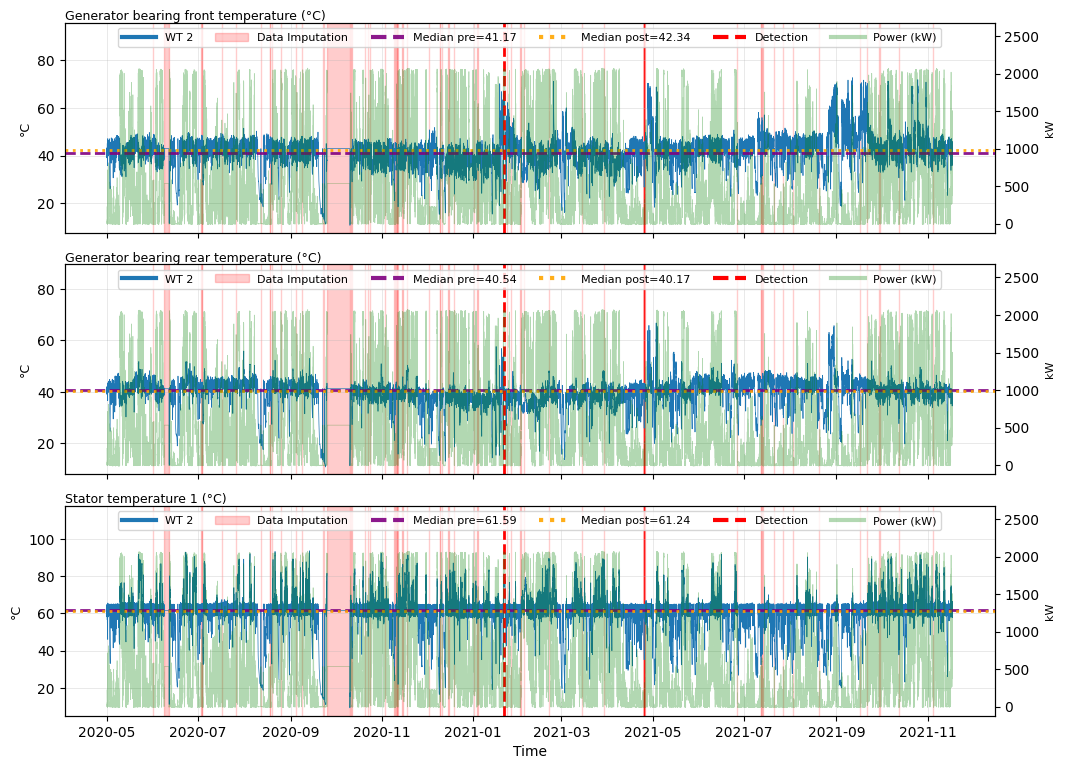

In [ ]:
pp.plot_signals_compact(df=wt_df,
                        wt_id = wt,
                        signals=gen_sigs,
                        anomaly_spans= None,
                        fig_size=(12,3),
                        ts_mark=[detection_ts],
                        ts_range=(detection_ts- pd.Timedelta(days=300),detection_ts + pd.Timedelta(days=300)),
                        mean_linewidth=2.0,
                        plot_power= True,
                        power_col = "Power (kW)",
                        power_alpha = 0.3,
                        power_linewidth = 0.5,
                        sig_linewidth=0.5,
                        save_path=Path(ic.PATH_PRINTS/ f"p2-33_signals_compact_rel_sigs_wt_{wt}")
                        )

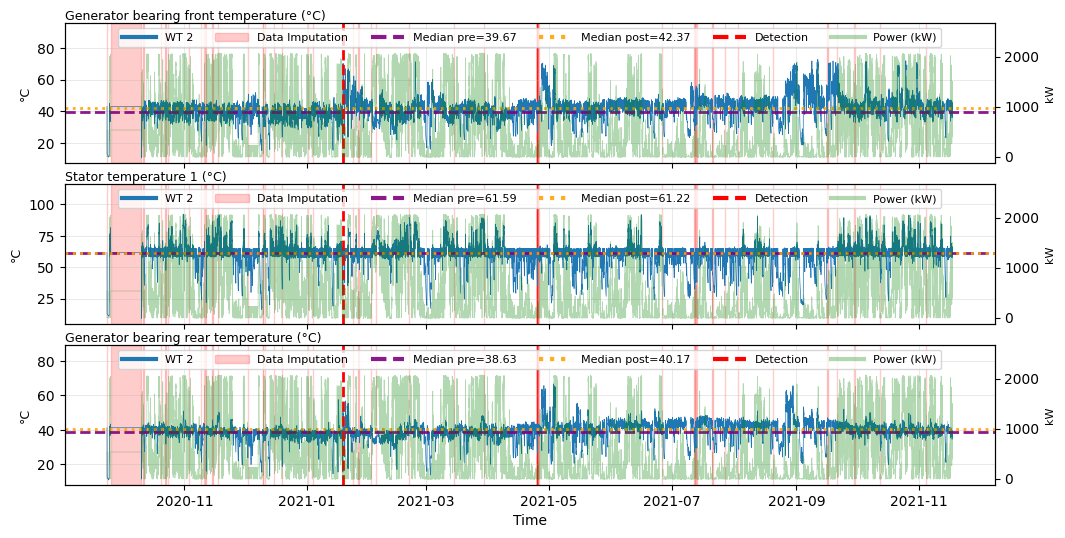

In [ ]:
pp.plot_signals_compact(df=wt_df,
                        wt_id = wt,
                        signals=relevant_sigs,
                        anomaly_spans= None,
                        fig_size=(12,2),
                        ts_mark=[maintenance],
                        ts_range=(detection_ts- pd.Timedelta(days=120),detection_ts + pd.Timedelta(days=300)),
                        mean_linewidth=2.0,
                        plot_power= True,
                        power_col = "Power (kW)",
                        power_alpha = 0.3,
                        power_linewidth = 0.5,
                        sig_linewidth=0.5,
                        save_path=Path(ic.PATH_PRINTS/ f"p2-33_signals_compact_rel_sigs_wt_{wt}")
                        )

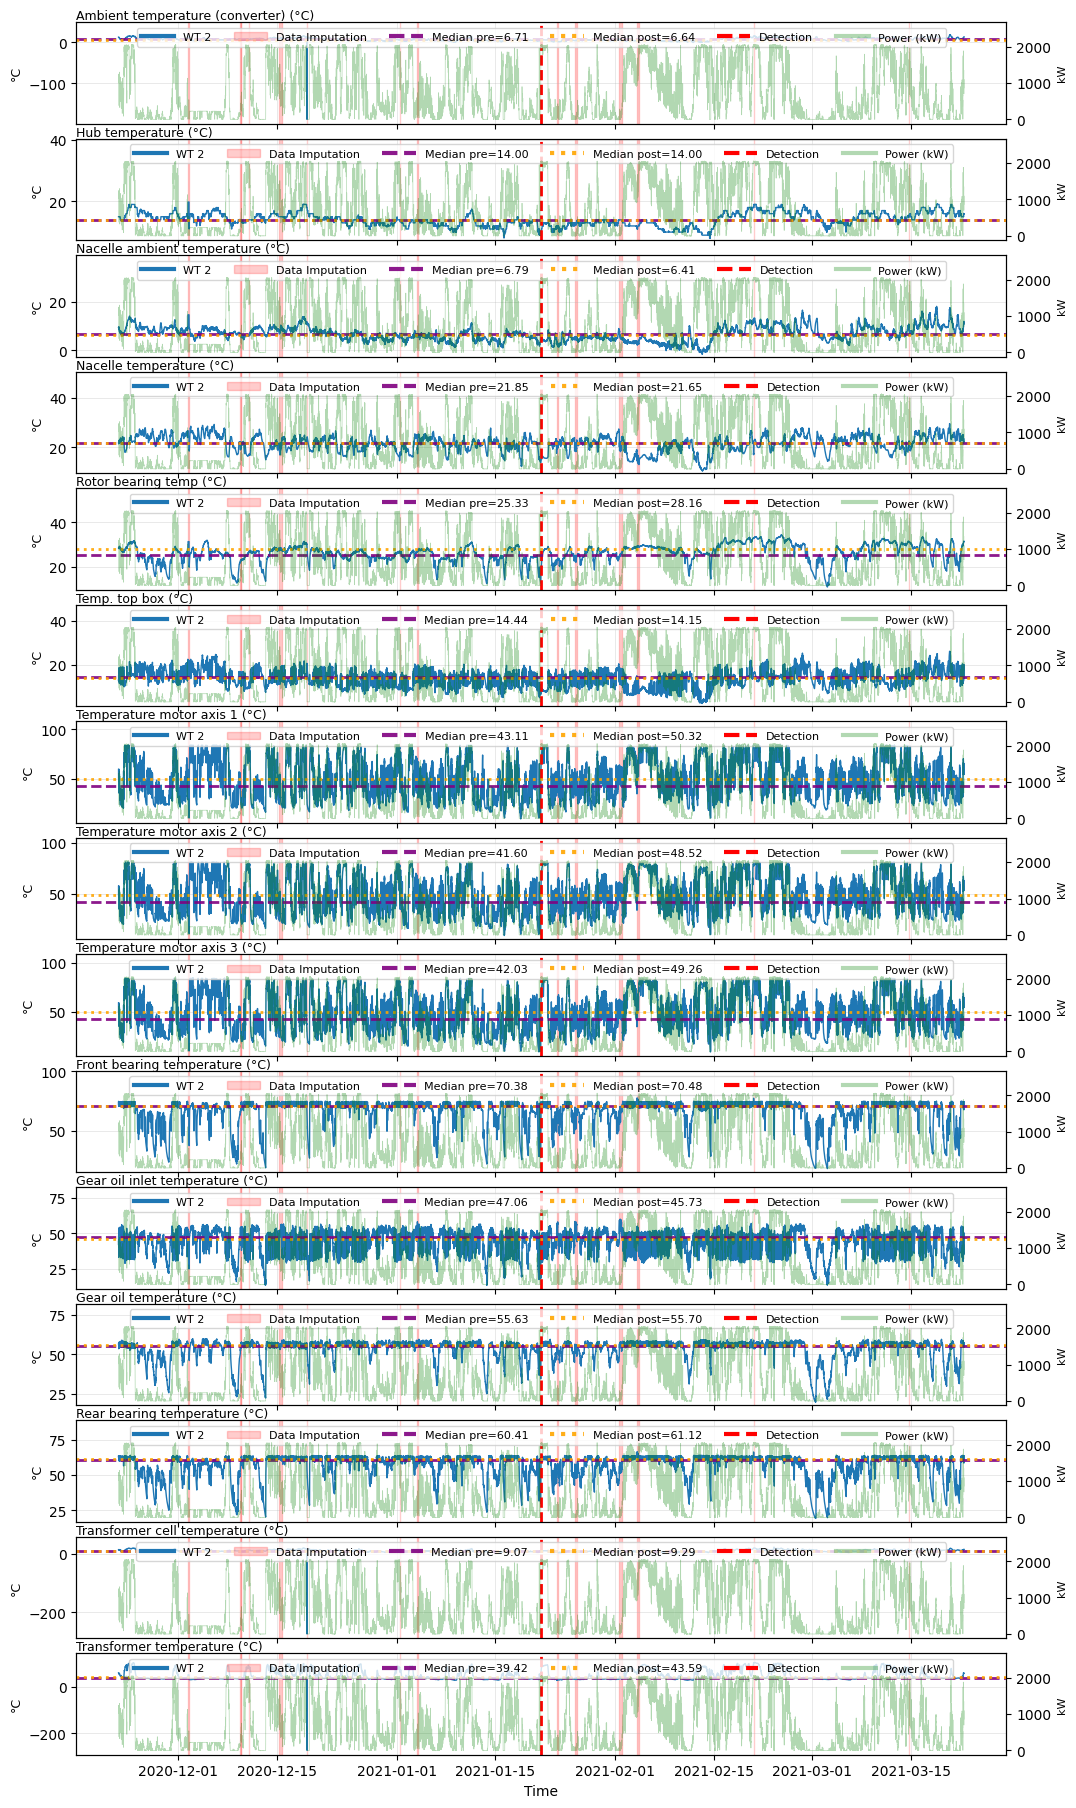

In [ ]:
pp.plot_signals_compact(df=wt_df,
                        wt_id = wt,
                        signals=[sig for sig in thermal_signals if sig not in relevant_sigs],
                        anomaly_spans= None,
                        fig_size=(12,1.5),
                        ts_mark=[detection_ts],
                        ts_range=(detection_ts- pd.Timedelta(days=60),detection_ts + pd.Timedelta(days=60)),
                        mean_linewidth=2.0,
                        plot_power= True,
                        power_col = "Power (kW)",
                        power_alpha = 0.3,
                        power_linewidth = 0.5,
                        sig_linewidth=1,
                        save_path=Path(ic.PATH_PRINTS / f"p2-33-rest_signals_compact_wt_{wt}.png")
                        )

Drive train acceleration (mm/ss)
Gear oil inlet pressure (bar)
Gear oil pump pressure (bar)
Gearbox speed (RPM)
Generator RPM (RPM)
Motor current axis 1 (A)
Motor current axis 2 (A)
Motor current axis 3 (A)
Nacelle position (°)
Power (kW)
Rotor speed (RPM)
Vane position 1+2 (°)
Wind direction (°)
Wind speed (m/s)
Blade angle (pitch position) A (°)
Blade angle (pitch position) B (°)
Blade angle (pitch position) C (°)
Tower Acceleration X (mm/ss)
Tower Acceleration Y (mm/ss)
Yaw bearing angle (°)


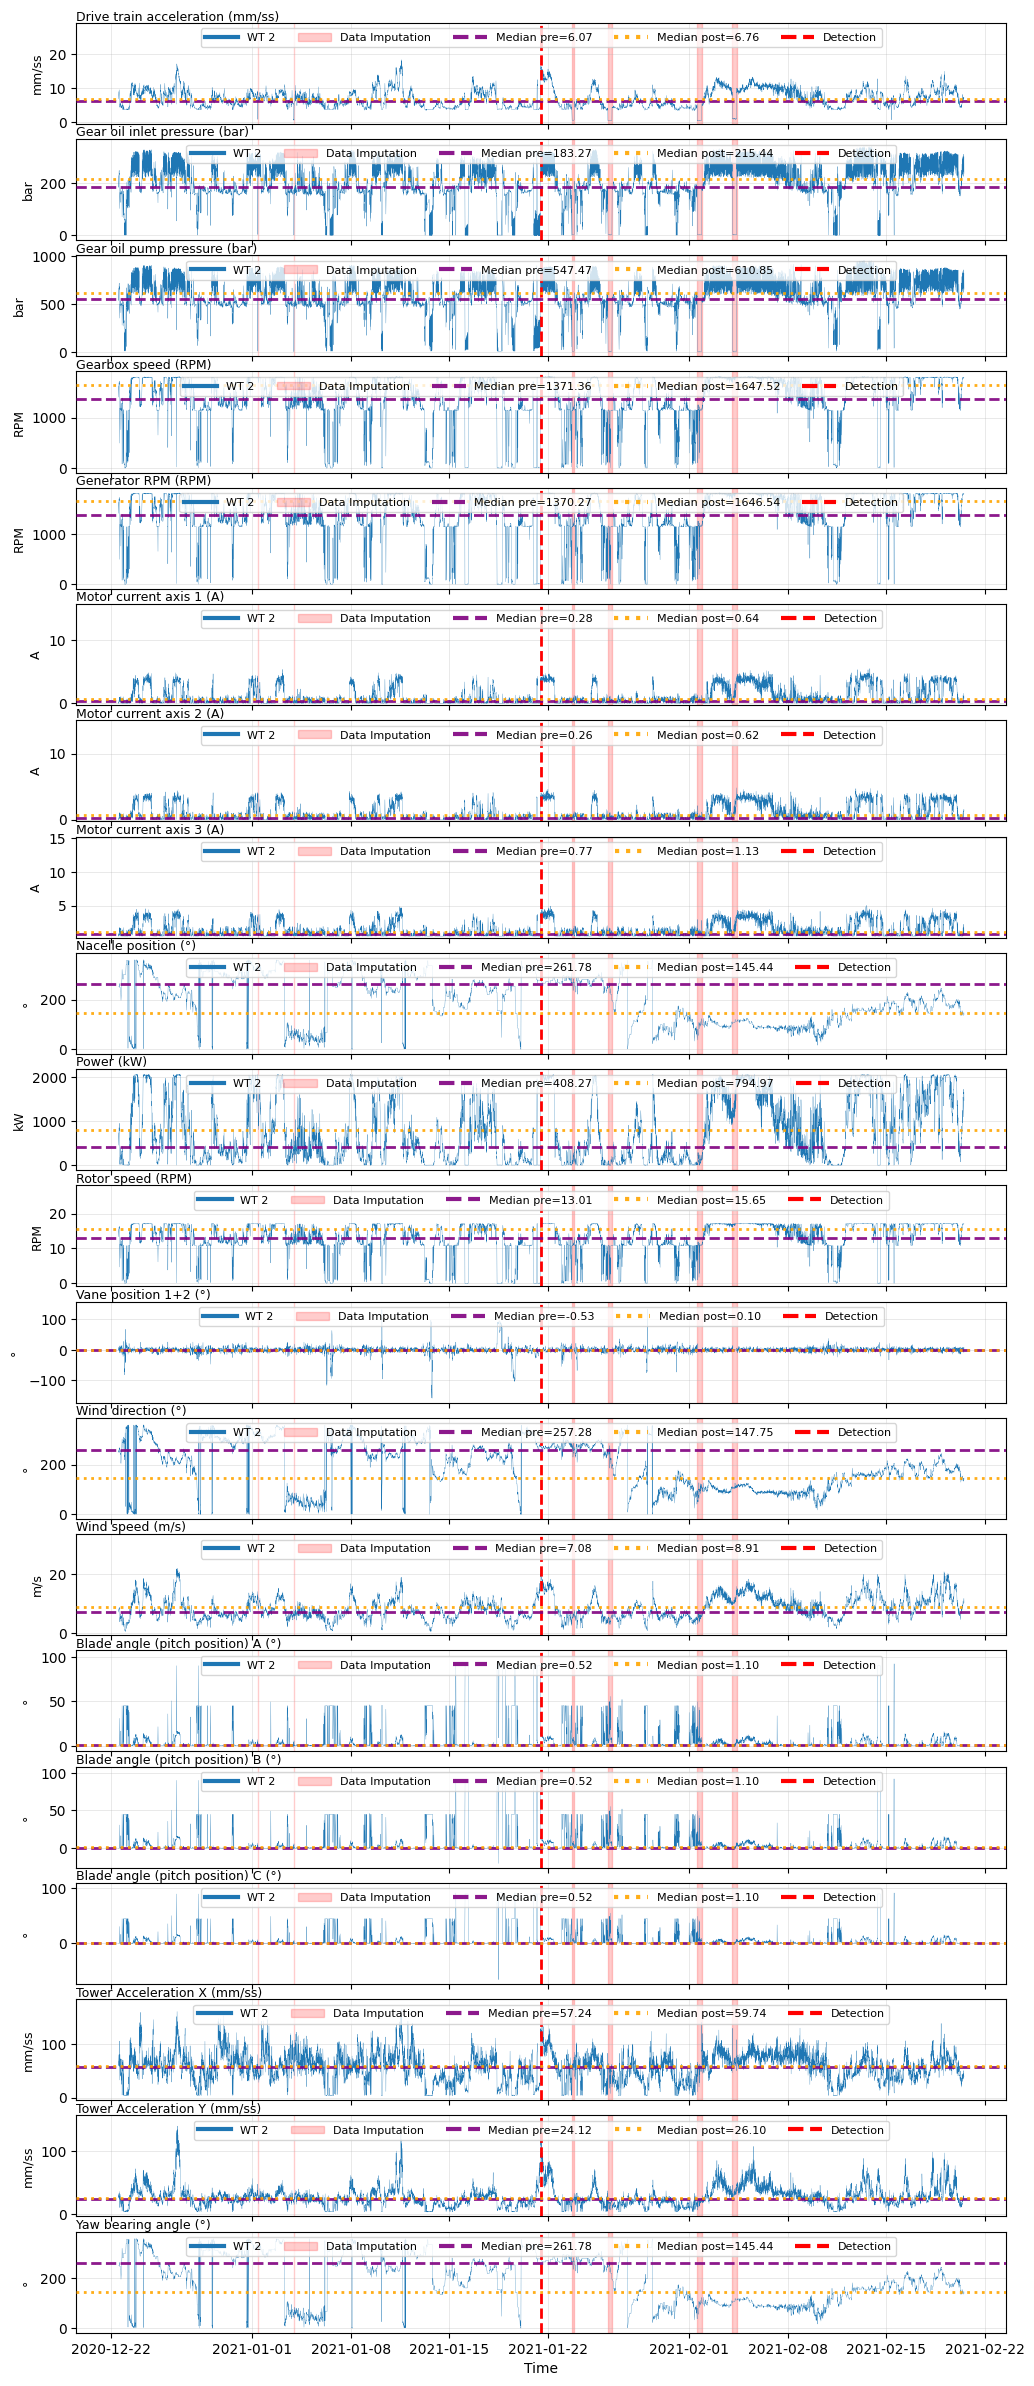

In [ ]:
signals = [sig for sig in hfn.load_feature_order() if "(°C)" not in sig]
for sig in signals:
    print(sig)
    
pp.plot_signals_compact(df=wt_df,
                        wt_id = wt,
                        signals=signals,
                        anomaly_spans= None,
                        fig_size=(12,1.5),
                        ts_mark=date,
                        ts_range=(date - pd.Timedelta(days=30), date + pd.Timedelta(days=30)),
                        mean_linewidth=2.0
                        )